# Quick start: a first look at any release

This notebook works the same way for all 22 releases. Set `RELEASE` in the next cell to any name in Table 1 and run the notebook from the top. It starts with `tsukuba`, a single building battery that downloads automatically (2.7 GB).

What it does, step by step:

1. Lists the units in the release (vehicles, storage systems, devices).
2. Loads a small slice of one unit. Most releases are far too large to load whole, so each release has a preset slice (one month, one year, one file part, or the first rows) recorded in `fielddata/quickstart.py`.
3. Shows the columns as the authors released them.
4. Plots one signal, usually a voltage, so you can see the data is real and sensible.

The release must already be downloaded, and the data folder set in `config/local.toml` (or the `FIELDDATA_DATA_ROOT` environment variable). See `docs/QUICKSTART.md`. For a deeper look at one release, open its own notebook in `notebooks/`.

In [1]:
# In Google Colab, install the package from GitHub and keep the data in /content/data.
# A local checkout needs nothing here: the data folder comes from config/local.toml.
import os
import subprocess
import sys

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install",
        "git+https://github.com/Astrolabe-Analytics/public-battery-field-data.git",
    ])
    os.environ["FIELDDATA_DATA_ROOT"] = "/content/data"
    print("Installed public-battery-field-data from GitHub; data goes to /content/data.")
else:
    print("Not in Colab: using the local installation or repository checkout.")

Not in Colab: using the local installation or repository checkout.


In [2]:
RELEASE = "tsukuba"  # any release name from Table 1, for example "cloverleaf", "tumftm" or "rwth-home"

In [3]:
# In Colab, download the release first. Releases that need a browser download (fetch prints the steps)
# cannot be fetched here; use one of the one-command releases, such as tsukuba or cloverleaf.
if IN_COLAB:
    subprocess.check_call([sys.executable, "-m", "fielddata.fetch", RELEASE, "--to", os.environ["FIELDDATA_DATA_ROOT"]])
else:
    print("Not in Colab: reading the release from the data folder set in config/local.toml.")

Not in Colab: reading the release from the data folder set in config/local.toml.


## 1. Units in the release

Each row is one unit as this collection counts it (Table 2). The columns describe where each unit's data lives in the deposit.

In [4]:
from pathlib import Path
import sys

try:
    import fielddata  # installed with pip install -e .
except ModuleNotFoundError:
    # not installed: find the repository folder above this notebook and import from there
    ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / 'fielddata').exists())
    sys.path.insert(0, str(ROOT))
    import fielddata
from fielddata import quickstart

units = fielddata.systems(RELEASE)
print(f"{RELEASE}: {len(units)} units")
units.head()

tsukuba: 1 units


,unit,raw_files,cleaned_files,first_day,last_day
0,tsukuba,118,119,2015-01-01,2018-04-24


## 2. Load a small slice of one unit

`quickstart.sample()` calls the release's loader with the preset arguments shown below. To look at a different unit or period, pass your own, for example `quickstart.sample("rwth-home", unit="05", month="2020-01")`.

In [5]:
print("load arguments:", quickstart.example_args(RELEASE))
frame = quickstart.sample(RELEASE)
print(f"{len(frame):,} rows, {len(frame.columns)} columns")

load arguments: {'start': '2016-06-01', 'end': '2016-06-08'}


691,200 rows, 12 columns


## 3. Columns as released

Column names and units are the authors' own, and nothing is renamed or converted here. Each release's `fielddata/loaders/<release>_SCHEMA.md` explains them.

In [6]:
frame.head()

,battery_active_power,battery_dc_voltage,battery_dc_current,grid_point_voltage,grid_point_active_power,pv_active_power,battery_active_power_setpoint,battery_soc,pv1_active_power,pv2_active_power,pv3_active_power,pv4_active_power
time,,,,,,,,,,,,
2016-06-01 00:00:00,-0.825,345.293762,0.0625,6466.50,567.599976,0.0,0.0,95.0,0.0,0.0,0.0,0.0
2016-06-01 00:00:01,-0.900,346.303741,0.0625,6471.00,566.400024,0.0,0.0,95.0,0.0,0.0,0.0,0.0
2016-06-01 00:00:02,-0.900,345.798737,-0.2500,6466.50,571.200012,0.0,0.0,95.0,0.0,0.0,0.0,0.0
2016-06-01 00:00:03,-0.975,344.915009,-0.2500,6466.50,571.200012,0.0,0.0,95.0,0.0,0.0,0.0,0.0
2016-06-01 00:00:04,-0.975,346.177490,-0.5625,6459.75,571.200012,0.0,0.0,95.0,0.0,0.0,0.0,0.0


## 4. Plot one signal

The plot shows one signal from the slice, chosen in `quickstart.PLOT`. Gaps, flat lines and spikes are usually real features of the release (the logger was off, the battery was idle, or a reading was invalid) rather than loading errors. The release's own notebook looks at them in detail.

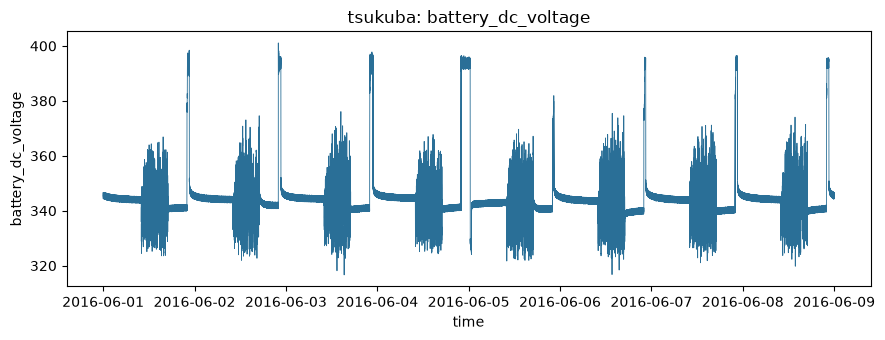

In [7]:
import matplotlib.pyplot as plt

ax = quickstart.plot(RELEASE, frame)
plt.tight_layout()
plt.show()

## 5. Optional: every release in turn

This loops over all 22 releases with the same three calls. It reads several GB in total and takes a few minutes, so it is switched off by default.

In [8]:
RUN_ALL = False
if RUN_ALL:
    for name in quickstart.EXAMPLES:
        f = quickstart.sample(name)
        quickstart.plot(name, f)
        plt.show()